In [5]:
import pytbl
import panel
import pandas as pd
import warnings
import numpy as np
from datetime import datetime
from tqdm import tqdm
from joblib import Parallel, delayed
from concurrent.futures import ThreadPoolExecutor
from IPython import get_ipython
from IPython.display import display, Javascript
from IPython import get_ipython
from IPython import get_ipython
ip = get_ipython()
path = None
if '__vsc_ipynb_file__' in ip.user_ns:
    path = ip.user_ns['__vsc_ipynb_file__']
pd.set_option('display.max_rows', 200)
pd.set_option('display.max_columns', 50)
warnings.filterwarnings("ignore")
begDate    = "20200130"
endData    = "20201123"
sampleDate = "20210421"

from busdates import PortableBusDates
from tqdm import tqdm
pbd = PortableBusDates()
tradingdays = pbd.get_range(begDate, endData)
nodatelist = pbd.get_range("20201123", "20210421")
preface_tradingdays = pbd.get_range(pbd.prev_date(begDate, 122), begDate) + tradingdays
alpha_name = 'timedelay2'# path.split('.')[0].split('/')[-1]

In [ ]:
# root_dir = '/data/beef3/mike/pshared/GAlpha_custom_build/wensheng_jawN9J/'
# sample_1min_df = pytbl.tbl_read(f"{root_dir}{alpha_name}/{20250401}.tbl")
# sample_1min_df['timeHMSf'] = sample_1min_df['rec_epoch'].apply(lambda timestamp: datetime.fromtimestamp(timestamp).strftime("%H:%M:%S.%f"))
# sample_1min_df.set_index(['sid','timeHMSf'], inplace=True)
# sample_1min_df.sort_index().head(200)

In [6]:

# sampleDate = "20240409"
root_dir = '/data/beef3/mike/pshared/GAlpha_custom_build/wensheng_jawN9J/'
def loadingfeaturetbl(sampleDate, alpha_name):
    # sample_1min_df = pytbl.tbl_read(f"{root_dir}demo_3/{sampleDate}.tbl")
    sample_1min_df = panel.sdiv2df(
        panel.read(f"{root_dir}{alpha_name}/terms.{sampleDate}.sdiv")
    )
    return sample_1min_df


Process_1min_df = Parallel(n_jobs=100, verbose=10)(
    delayed(loadingfeaturetbl)(sampleDate, alpha_name) for sampleDate in tqdm(tradingdays)
)
feature_1min_df = pd.concat(Process_1min_df, ignore_index=True)
# feature_1min_df = feature_1min_df.reset_index()
feature_1min_df['sid'] = feature_1min_df['sid'].astype(int).astype(str)
feature_1min_df = feature_1min_df.set_index(['sid','date','time']).sort_index()

100%|██████████| 199/199 [00:01<00:00, 131.94it/s]
[Parallel(n_jobs=100)]: Done   1 tasks      | elapsed:    6.2s
[Parallel(n_jobs=100)]: Done  20 out of 199 | elapsed:    7.1s remaining:  1.1min
[Parallel(n_jobs=100)]: Done  40 out of 199 | elapsed:    7.9s remaining:   31.5s
[Parallel(n_jobs=100)]: Done  60 out of 199 | elapsed:    8.7s remaining:   20.2s
[Parallel(n_jobs=100)]: Done  80 out of 199 | elapsed:    9.5s remaining:   14.1s
[Parallel(n_jobs=100)]: Done 100 out of 199 | elapsed:   10.3s remaining:   10.2s
[Parallel(n_jobs=100)]: Done 120 out of 199 | elapsed:   11.0s remaining:    7.3s
[Parallel(n_jobs=100)]: Done 140 out of 199 | elapsed:   11.7s remaining:    5.0s
[Parallel(n_jobs=100)]: Done 160 out of 199 | elapsed:   12.4s remaining:    3.0s
[Parallel(n_jobs=100)]: Done 180 out of 199 | elapsed:   13.1s remaining:    1.4s
[Parallel(n_jobs=100)]: Done 199 out of 199 | elapsed:   13.8s finished


In [4]:
# # import gc
# # gc.collect()
# feature_1min_df.columns

In [5]:
# univ = 'midx'
# label_dir = '/data/beer2/data/CA.LTS/CNEQ/Panels/'
# def load_labels_1min(sampleDate, univ):
#     Omin_label = panel.sdiv2df(
#         panel.read(f"{label_dir}Y/Y_v5_1min/terms.{sampleDate}.sdiv").sel(V=slice('ret1h','ret0e'))
#     )
#     active = panel.sdiv2df(
#         panel.read(f"{label_dir}I/fq1m/BB/terms.{sampleDate}.sdiv").sel(V=slice('is.active','is.active'))
#     )
#     univ = panel.sdiv2df(
#         panel.read(f"{label_dir}D/bod/univ/univ-{sampleDate}.sdiv").sel(V=slice(f"{univ}", f"{univ}"))
#     )
#     return Omin_label, active, univ
# Process_label_df = Parallel(n_jobs=100, verbose=10)(
#     delayed(load_labels_1min)(sampleDate, univ) for sampleDate in tqdm(tradingdays)
# )
# label_df  = pd.concat([Process[0] for Process in Process_label_df], ignore_index=True).set_index(['sid','date','time'])
# weight_df = pd.concat([Process[1] for Process in Process_label_df], ignore_index=True).set_index(['sid','date','time'])
# univ_df   = pd.concat([Process[2] for Process in Process_label_df], ignore_index=True).set_index(['sid','date'])

# label_df = label_df.merge(weight_df[['is.active']], left_index=True, right_index=True, how='left')
# label_df = label_df.merge(univ_df, left_index=True, right_index=True, how='left')
# label_df = label_df[label_df[f'{univ}']>0]

# label_df['ret0e_shift'] = label_df.groupby(['sid','date'], group_keys=False)['ret0e'].shift(-1)
# label_df['ret1h_shift'] = label_df.groupby(['sid','date'], group_keys=False)['ret1h'].shift(-1)
# label_df.to_parquet("/data/nfshome/wensheng/git/wensheng_jawN9J/label_df.parquet", engine="pyarrow", compression="snappy")

In [7]:
# sampleDate = "20240409"
root_dir = '/data/nfs0/chinaEquityData/panel/'
def loadingfeaturetbl(sampleDate, alpha_name):
    # sample_1min_df = pytbl.tbl_read(f"{root_dir}demo_3/{sampleDate}.tbl")
    sample_1min_df = panel.sdiv2df(
        panel.read(f"{root_dir}5min/5min-{sampleDate}.sdiv").sel(V = slice("midPriceLastValid", "close.avg"))
    )
    return sample_1min_df


Process_1min_df_2 = Parallel(n_jobs=100, verbose=10)(
    delayed(loadingfeaturetbl)(sampleDate, alpha_name) for sampleDate in tqdm(tradingdays)
)
feature_1min_df_2 = pd.concat(Process_1min_df_2, ignore_index=True)
feature_1min_df_2 = feature_1min_df_2.set_index(['sid','date','time'])

100%|██████████| 199/199 [00:00<00:00, 28122.19it/s]
[Parallel(n_jobs=100)]: Done   1 tasks      | elapsed:    0.7s
[Parallel(n_jobs=100)]: Done  20 out of 199 | elapsed:    2.2s remaining:   19.8s
[Parallel(n_jobs=100)]: Done  40 out of 199 | elapsed:    3.8s remaining:   15.0s
[Parallel(n_jobs=100)]: Done  60 out of 199 | elapsed:    5.4s remaining:   12.4s
[Parallel(n_jobs=100)]: Done  80 out of 199 | elapsed:    6.9s remaining:   10.3s
[Parallel(n_jobs=100)]: Done 100 out of 199 | elapsed:    8.6s remaining:    8.5s
[Parallel(n_jobs=100)]: Done 120 out of 199 | elapsed:   10.3s remaining:    6.8s
[Parallel(n_jobs=100)]: Done 140 out of 199 | elapsed:   12.2s remaining:    5.1s
[Parallel(n_jobs=100)]: Done 160 out of 199 | elapsed:   13.9s remaining:    3.4s
[Parallel(n_jobs=100)]: Done 180 out of 199 | elapsed:   15.8s remaining:    1.7s
[Parallel(n_jobs=100)]: Done 199 out of 199 | elapsed:   17.5s finished


In [8]:
label_df = pd.read_feather("/data/beef3/mike/pshared/GAlpha_custom_build/wensheng_jawN9J/label_df_2020_202011.feather")



feature_1min_df['close.avg'] = feature_1min_df_2['close.avg']
feature_1min_df['close.avg'] = feature_1min_df['close.avg'].replace(0.0, np.nan)



feature_1min_df['passive_B_mean_delay_divadd'] = (feature_1min_df['passive_B_mean_delay'] ) / (feature_1min_df['passive_B_mean_delay'] + feature_1min_df['passive_S_mean_delay'] ) 
feature_1min_df['passive_S_mean_delay_divadd'] = (feature_1min_df['passive_S_mean_delay'] ) / (feature_1min_df['passive_B_mean_delay'] + feature_1min_df['passive_S_mean_delay'] ) 
feature_1min_df['passive_BS_mean_delay_divadd'] = (feature_1min_df['passive_S_mean_delay'] - feature_1min_df['passive_B_mean_delay'] ) / (feature_1min_df['passive_B_mean_delay'] + feature_1min_df['passive_S_mean_delay'] ) 

feature_1min_df['passive_B_std_delay_divadd'] = (feature_1min_df['passive_B_std_delay'] ) / (feature_1min_df['passive_B_mean_delay'] + feature_1min_df['passive_S_mean_delay'] ) 
feature_1min_df['passive_S_std_delay_divadd'] = (feature_1min_df['passive_S_std_delay'] ) / (feature_1min_df['passive_B_mean_delay'] + feature_1min_df['passive_S_mean_delay'] ) 
feature_1min_df['passive_BS_std_delay_divadd'] = (feature_1min_df['passive_S_std_delay'] - feature_1min_df['passive_B_std_delay'] ) / (feature_1min_df['passive_B_mean_delay'] + feature_1min_df['passive_S_mean_delay'] ) 
feature_1min_df['passive_BS_std_delay_divaddstd'] = (feature_1min_df['passive_S_std_delay'] - feature_1min_df['passive_B_std_delay'] ) / (feature_1min_df['passive_B_std_delay'] + feature_1min_df['passive_S_std_delay'] ) 


feature_1min_df['passive_B_mean_ratio_divadd'] = (feature_1min_df['passive_B_mean_ratio'] ) / (feature_1min_df['passive_B_mean_ratio'] + feature_1min_df['passive_S_mean_ratio'] ) 
feature_1min_df['passive_S_mean_ratio_divadd'] = (feature_1min_df['passive_S_mean_ratio'] ) / (feature_1min_df['passive_B_mean_ratio'] + feature_1min_df['passive_S_mean_ratio'] ) 
feature_1min_df['passive_BS_mean_ratio_divadd'] = (feature_1min_df['passive_S_mean_ratio'] - feature_1min_df['passive_B_mean_ratio'] ) / (feature_1min_df['passive_B_mean_ratio'] + feature_1min_df['passive_S_mean_ratio'] ) 

feature_1min_df['passive_B_std_ratio_divadd'] = (feature_1min_df['passive_B_std_ratio'] ) / (feature_1min_df['passive_B_mean_ratio'] + feature_1min_df['passive_S_mean_ratio'] ) 
feature_1min_df['passive_S_std_ratio_divadd'] = (feature_1min_df['passive_S_std_ratio'] ) / (feature_1min_df['passive_B_mean_ratio'] + feature_1min_df['passive_S_mean_ratio'] ) 
feature_1min_df['passive_BS_std_ratio_divadd'] = (feature_1min_df['passive_S_std_ratio'] - feature_1min_df['passive_B_std_ratio'] ) / (feature_1min_df['passive_B_mean_ratio'] + feature_1min_df['passive_S_mean_ratio'] ) 
feature_1min_df['passive_BS_std_ratio_divaddstd'] = (feature_1min_df['passive_S_std_ratio'] - feature_1min_df['passive_B_std_ratio'] ) / (feature_1min_df['passive_B_std_ratio'] + feature_1min_df['passive_S_std_ratio'] ) 



feature_1min_df['passive_B_mean_20diff_divadd'] = (feature_1min_df['passive_B_mean_20diff'] ) / (feature_1min_df['passive_B_mean_20diff'] + feature_1min_df['passive_S_mean_20diff'] ) 
feature_1min_df['passive_S_mean_20diff_divadd'] = (feature_1min_df['passive_S_mean_20diff'] ) / (feature_1min_df['passive_B_mean_20diff'] + feature_1min_df['passive_S_mean_20diff'] ) 
feature_1min_df['passive_BS_mean_20diff_divadd'] = (feature_1min_df['passive_S_mean_20diff'] - feature_1min_df['passive_B_mean_20diff'] ) / (feature_1min_df['passive_B_mean_20diff'] + feature_1min_df['passive_S_mean_20diff'] ) 

feature_1min_df['passive_B_std_20diff_divadd'] = (feature_1min_df['passive_B_std_20diff'] ) / (feature_1min_df['passive_B_mean_20diff'] + feature_1min_df['passive_S_mean_20diff'] ) 
feature_1min_df['passive_S_std_20diff_divadd'] = (feature_1min_df['passive_S_std_20diff'] ) / (feature_1min_df['passive_B_mean_20diff'] + feature_1min_df['passive_S_mean_20diff'] ) 
feature_1min_df['passive_BS_std_20diff_divadd'] = (feature_1min_df['passive_S_std_20diff'] - feature_1min_df['passive_B_std_20diff'] ) / (feature_1min_df['passive_B_mean_20diff'] + feature_1min_df['passive_S_mean_20diff'] ) 
feature_1min_df['passive_BS_std_20diff_divaddstd'] = (feature_1min_df['passive_S_std_20diff'] - feature_1min_df['passive_B_std_20diff'] ) / (feature_1min_df['passive_B_std_20diff'] + feature_1min_df['passive_S_std_20diff'] ) 



feature_1min_df['Mean_filteractBuydelayl_trQ_divall'] = (feature_1min_df['Mean_filteractBuydelayl_trQ'] ) / (feature_1min_df['QtyAdd_all'] ) 
feature_1min_df['Mean_filteractSelldelayl_trQ_divall'] = (feature_1min_df['Mean_filteractSelldelayl_trQ'] ) / (feature_1min_df['QtyAdd_all'] ) 
feature_1min_df['Mean_filteractdelayl_trQ_BSdivall'] = (feature_1min_df['Mean_filteractBuydelayl_trQ'] - feature_1min_df['Mean_filteractSelldelayl_trQ'] ) / (feature_1min_df['QtyAdd_all'] ) 
feature_1min_df['Mean_filteractdelayl_trQ_BSratio'] = (feature_1min_df['Mean_filteractBuydelayl_trQ'] - feature_1min_df['Mean_filteractSelldelayl_trQ'] ) / (feature_1min_df['Mean_filteractBuydelayl_trQ'] + feature_1min_df['Mean_filteractSelldelayl_trQ'] )
feature_1min_df['Mean_filteractdelayl_trQ_BSadddivall'] = (feature_1min_df['Mean_filteractBuydelayl_trQ'] + feature_1min_df['Mean_filteractSelldelayl_trQ'] ) / (feature_1min_df['QtyAdd_all'] ) 

feature_1min_df['Std_filteractBuydelayl_trQ_divall'] = (feature_1min_df['Std_filteractBuydelayl_trQ'] ) / (feature_1min_df['QtyAdd_all'] ) 
feature_1min_df['Std_filteractSelldelayl_trQ_divall'] = (feature_1min_df['Std_filteractSelldelayl_trQ'] ) / (feature_1min_df['QtyAdd_all'] ) 
feature_1min_df['Std_filteractdelayl_trQ_BSdivall'] = (feature_1min_df['Std_filteractBuydelayl_trQ'] - feature_1min_df['Std_filteractSelldelayl_trQ'] ) / (feature_1min_df['QtyAdd_all'] ) 
feature_1min_df['Std_filteractdelayl_trQ_BSratio'] = (feature_1min_df['Std_filteractBuydelayl_trQ'] - feature_1min_df['Std_filteractSelldelayl_trQ'] ) / (feature_1min_df['Mean_filteractBuydelayl_trQ'] + feature_1min_df['Mean_filteractSelldelayl_trQ'] )
feature_1min_df['Std_filteractdelayl_trQ_BSratiostd'] = (feature_1min_df['Std_filteractBuydelayl_trQ'] - feature_1min_df['Std_filteractSelldelayl_trQ'] ) / (feature_1min_df['Std_filteractBuydelayl_trQ'] + feature_1min_df['Std_filteractSelldelayl_trQ'] )
feature_1min_df['Std_filteractdelayl_trQ_BSadddivall'] = (feature_1min_df['Std_filteractBuydelayl_trQ'] + feature_1min_df['Std_filteractSelldelayl_trQ'] ) / (feature_1min_df['QtyAdd_all'] ) 



feature_1min_df['Mean_filteractBuyRatiosl_trQ_divall'] = (feature_1min_df['Mean_filteractBuyRatiosl_trQ'] ) / (feature_1min_df['QtyAdd_all'] ) 
feature_1min_df['Mean_filteractSellRatiosl_trQ_divall'] = (feature_1min_df['Mean_filteractSellRatiosl_trQ'] ) / (feature_1min_df['QtyAdd_all'] ) 
feature_1min_df['Mean_filteractRatiosl_trQ_BSdivall'] = (feature_1min_df['Mean_filteractBuyRatiosl_trQ'] - feature_1min_df['Mean_filteractSellRatiosl_trQ'] ) / (feature_1min_df['QtyAdd_all'] ) 
feature_1min_df['Mean_filteractRatiosl_trQ_BSratio'] = (feature_1min_df['Mean_filteractBuyRatiosl_trQ'] - feature_1min_df['Mean_filteractSellRatiosl_trQ'] ) / (feature_1min_df['Mean_filteractBuyRatiosl_trQ'] + feature_1min_df['Mean_filteractSellRatiosl_trQ'] )
feature_1min_df['Mean_filteractRatiosl_trQ_BSadddivall'] = (feature_1min_df['Mean_filteractBuyRatiosl_trQ'] + feature_1min_df['Mean_filteractSellRatiosl_trQ'] ) / (feature_1min_df['QtyAdd_all'] ) 

feature_1min_df['Std_filteractBuyRatiosl_trQ_divall'] = (feature_1min_df['Std_filteractBuyRatiosl_trQ'] ) / (feature_1min_df['QtyAdd_all'] ) 
feature_1min_df['Std_filteractSellRatiosl_trQ_divall'] = (feature_1min_df['Std_filteractSellRatiosl_trQ'] ) / (feature_1min_df['QtyAdd_all'] ) 
feature_1min_df['Std_filteractRatiosl_trQ_BSdivall'] = (feature_1min_df['Std_filteractBuyRatiosl_trQ'] - feature_1min_df['Std_filteractSellRatiosl_trQ'] ) / (feature_1min_df['QtyAdd_all'] ) 
feature_1min_df['Std_filteractRatiosl_trQ_BSratio'] = (feature_1min_df['Std_filteractBuyRatiosl_trQ'] - feature_1min_df['Std_filteractSellRatiosl_trQ'] ) / (feature_1min_df['Mean_filteractBuyRatiosl_trQ'] + feature_1min_df['Mean_filteractSellRatiosl_trQ'] )
feature_1min_df['Std_filteractRatiosl_trQ_BSratiostd'] = (feature_1min_df['Std_filteractBuyRatiosl_trQ'] - feature_1min_df['Std_filteractSellRatiosl_trQ'] ) / (feature_1min_df['Std_filteractBuyRatiosl_trQ'] + feature_1min_df['Std_filteractSellRatiosl_trQ'] )
feature_1min_df['Std_filteractRatiosl_trQ_BSadddivall'] = (feature_1min_df['Std_filteractBuyRatiosl_trQ'] + feature_1min_df['Std_filteractSellRatiosl_trQ'] ) / (feature_1min_df['QtyAdd_all'] ) 






feature_1min_df[f'Mean_filteractBSdelayl_addP_avg'] = ((feature_1min_df[f'Mean_filteractBuydelayl_addP'] + feature_1min_df[f'Mean_filteractSelldelayl_addP']) / 2).replace(0.0, np.nan)
feature_1min_df[f'Mean_filteractBSdelayl_addP_spreadratio'] = ((feature_1min_df[f'Mean_filteractBuydelayl_addP'] - feature_1min_df[f'Mean_filteractSelldelayl_addP']) / (feature_1min_df[f'Mean_filteractBuydelayl_addP'] + feature_1min_df[f'Mean_filteractSelldelayl_addP'])).replace(np.inf, np.nan).replace(-np.inf, np.nan)
feature_1min_df[f'Mean_filteractBSdelayl_addP_minusclose'] = ((feature_1min_df[f'Mean_filteractBSdelayl_addP_avg'] - feature_1min_df['close.avg']) / feature_1min_df[f'Mean_filteractBSdelayl_addP_avg']).replace(1.0, np.nan)
feature_1min_df[f'Mean_filteractBdelayl_addP_minusclose'] = ((feature_1min_df[f'Mean_filteractBuydelayl_addP'] - feature_1min_df['close.avg']) / feature_1min_df[f'close.avg']).replace(1.0, np.nan)
feature_1min_df[f'Mean_filteractSdelayl_addP_minusclose'] = ((feature_1min_df[f'Mean_filteractSelldelayl_addP'] - feature_1min_df['close.avg']) / feature_1min_df[f'close.avg']).replace(1.0, np.nan)
feature_1min_df[f'ret_Mean_filteractBSdelayl_addP'] = feature_1min_df.groupby(['sid','date'], group_keys=False)[f'Mean_filteractBSdelayl_addP_avg'].pct_change().replace(np.inf, np.nan).replace(-np.inf, np.nan)

feature_1min_df[f'Mean_filteractBSRatiosl_addP_avg'] = ((feature_1min_df[f'Mean_filteractBuyRatiosl_addP'] + feature_1min_df[f'Mean_filteractSellRatiosl_addP']) / 2).replace(0.0, np.nan)
feature_1min_df[f'Mean_filteractBSRatiosl_addP_spreadratio'] = ((feature_1min_df[f'Mean_filteractBuyRatiosl_addP'] - feature_1min_df[f'Mean_filteractSellRatiosl_addP']) / (feature_1min_df[f'Mean_filteractBuyRatiosl_addP'] + feature_1min_df[f'Mean_filteractSellRatiosl_addP'])).replace(np.inf, np.nan).replace(-np.inf, np.nan)
feature_1min_df[f'Mean_filteractBSRatiosl_addP_minusclose'] = ((feature_1min_df[f'Mean_filteractBSRatiosl_addP_avg'] - feature_1min_df['close.avg']) / feature_1min_df[f'Mean_filteractBSRatiosl_addP_avg']).replace(1.0, np.nan)
feature_1min_df[f'Mean_filteractBRatiosl_addP_minusclose'] = ((feature_1min_df[f'Mean_filteractBuyRatiosl_addP'] - feature_1min_df['close.avg']) / feature_1min_df[f'close.avg']).replace(1.0, np.nan)
feature_1min_df[f'Mean_filteractSRatiosl_addP_minusclose'] = ((feature_1min_df[f'Mean_filteractSellRatiosl_addP'] - feature_1min_df['close.avg']) / feature_1min_df[f'close.avg']).replace(1.0, np.nan)
feature_1min_df[f'ret_Mean_filteractBSRatiosl_addP'] = feature_1min_df.groupby(['sid','date'], group_keys=False)[f'Mean_filteractBSRatiosl_addP_avg'].pct_change().replace(np.inf, np.nan).replace(-np.inf, np.nan)



In [ ]:
# feature_1min_df['close.avg'] = feature_1min_df_2['close.avg']
# feature_1min_df['close']     = feature_1min_df_2['close']
# feature_1min_df['avg_minus_close'] = (feature_1min_df['close.avg'] - feature_1min_df['close']) / feature_1min_df['close']

In [9]:
feature_all_df = feature_1min_df.merge(label_df[['ret1h','ret0e','is.active','ret0e_shift','ret1h_shift']], left_index=True, right_index=True, how='inner')
feature_all_df = feature_all_df[(feature_all_df['is.active']>0)]

In [10]:
# feature_all_df.loc[:, 'ret1h_shift':].describe()

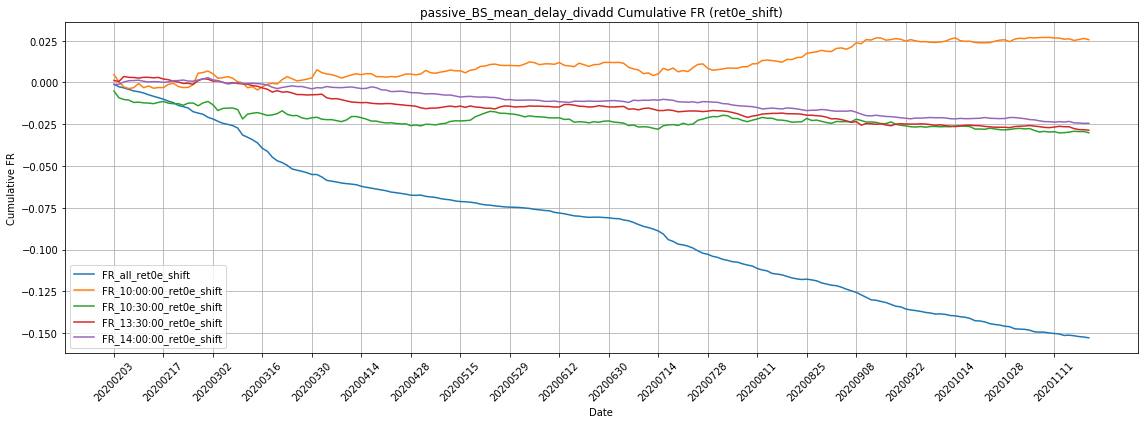

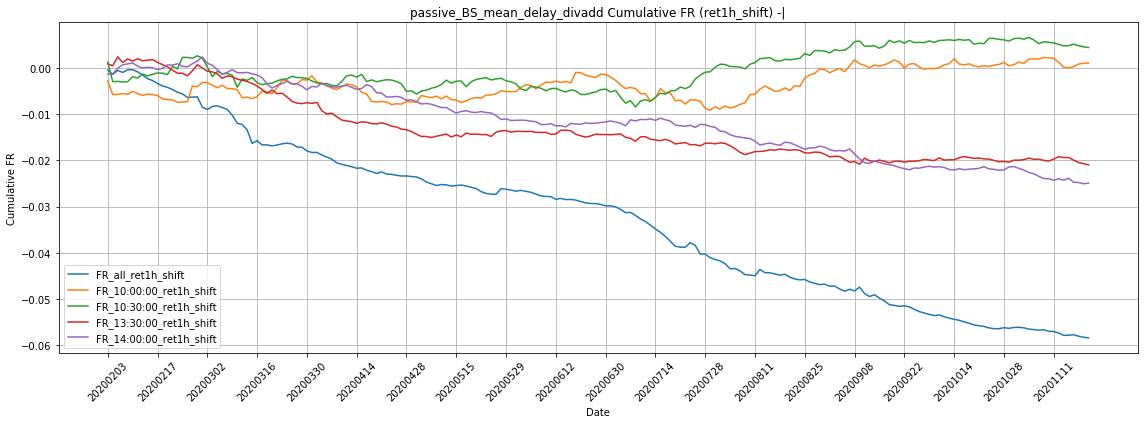

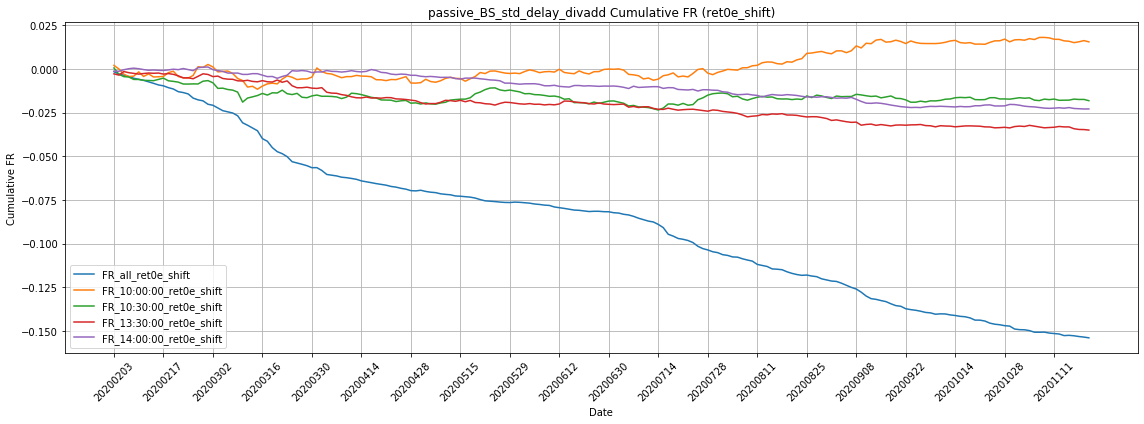

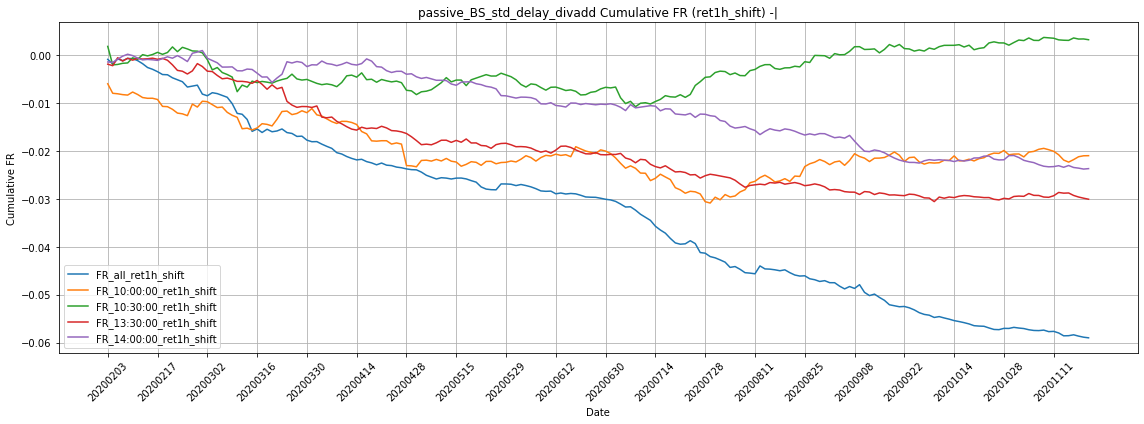

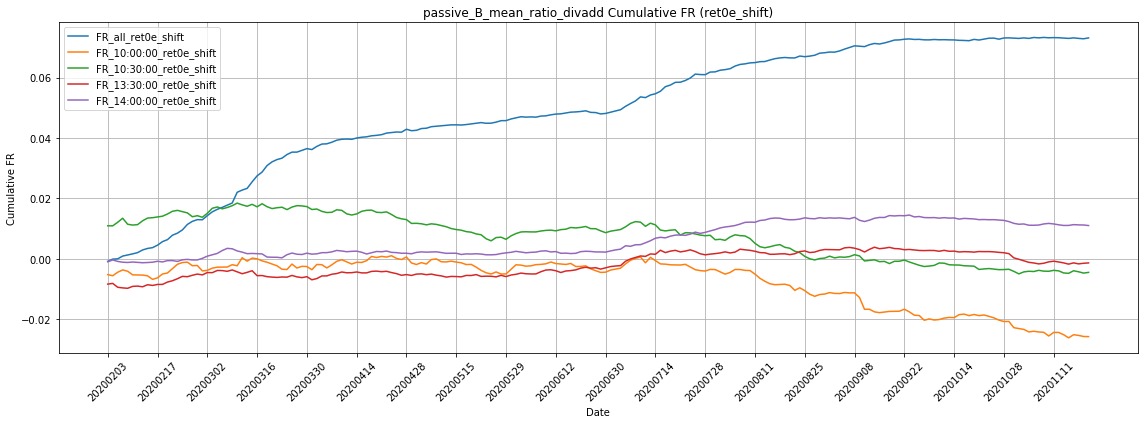

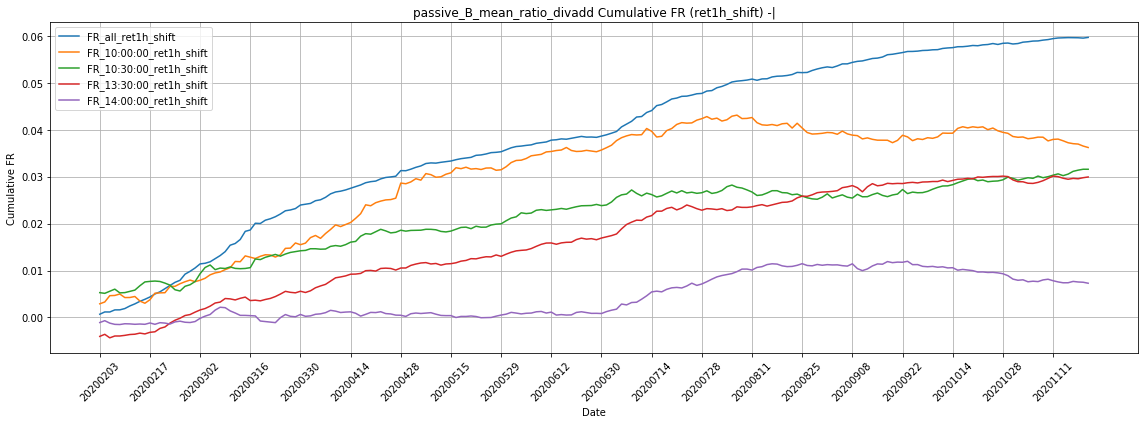

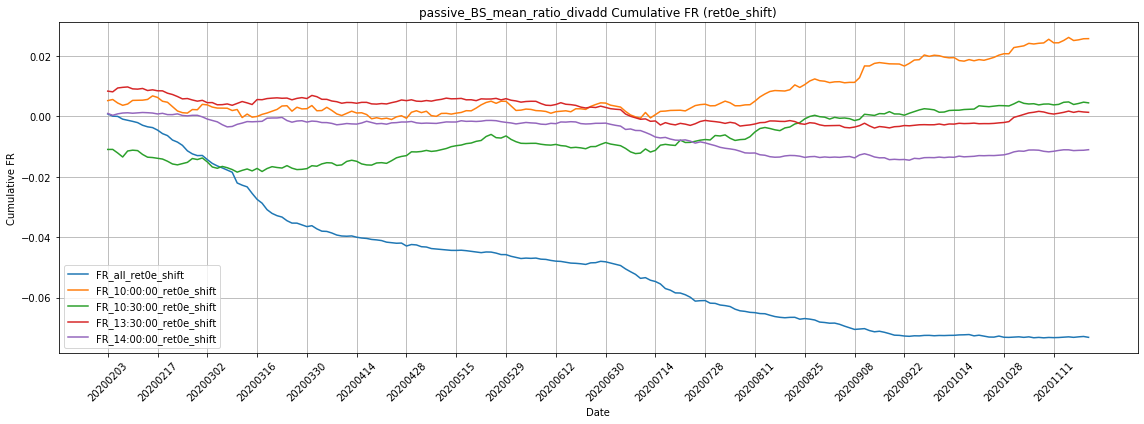

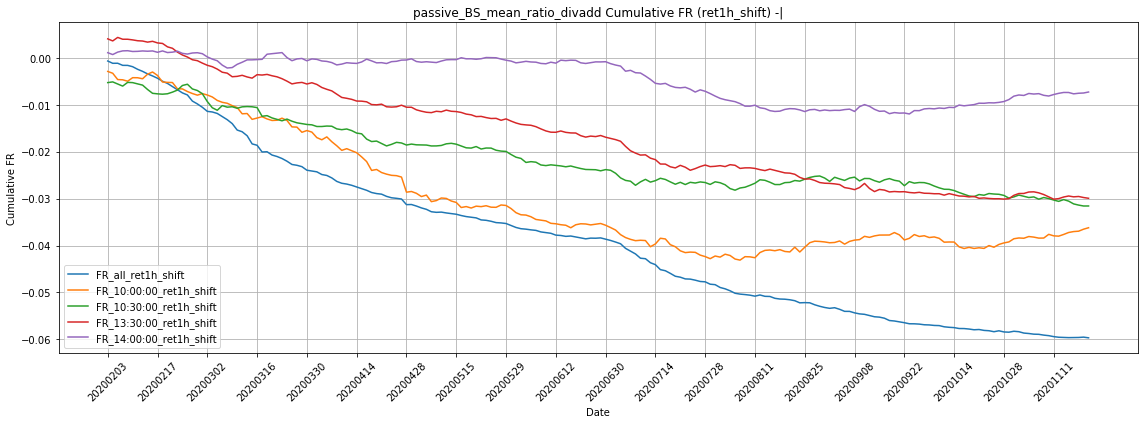

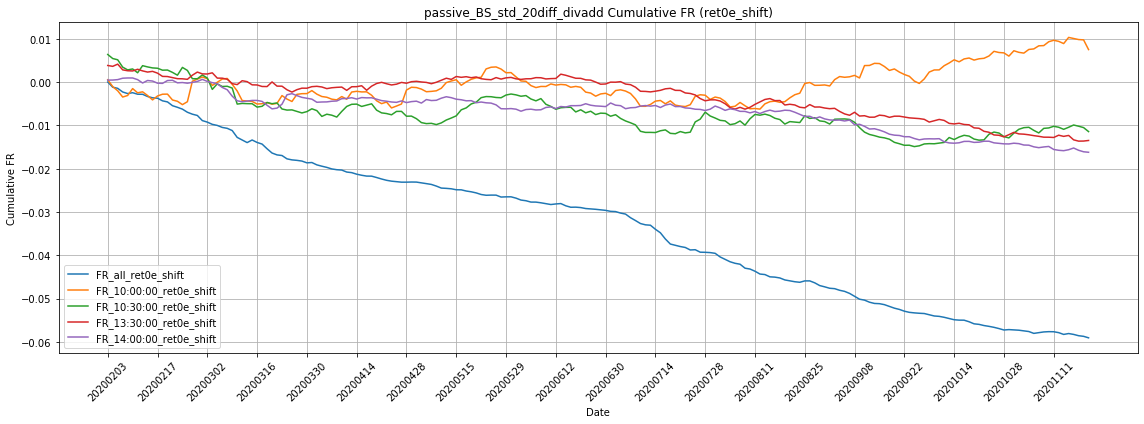

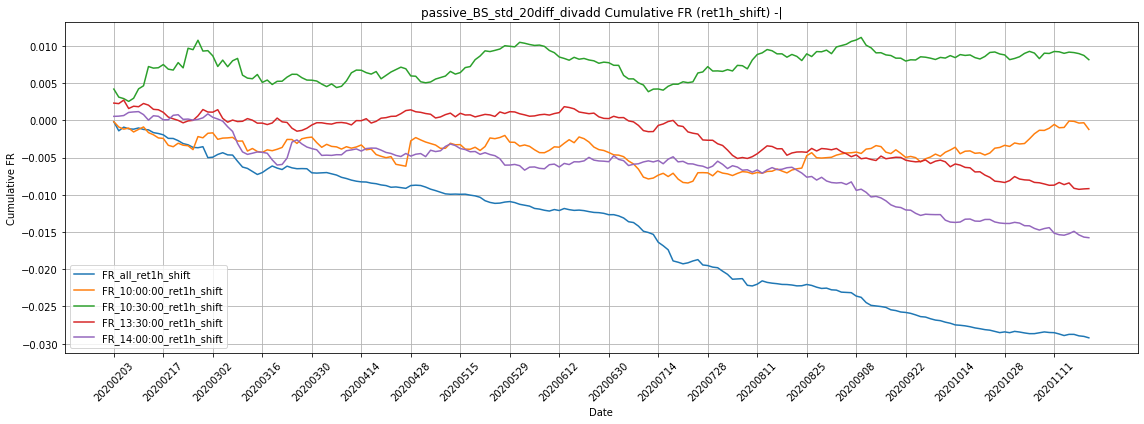

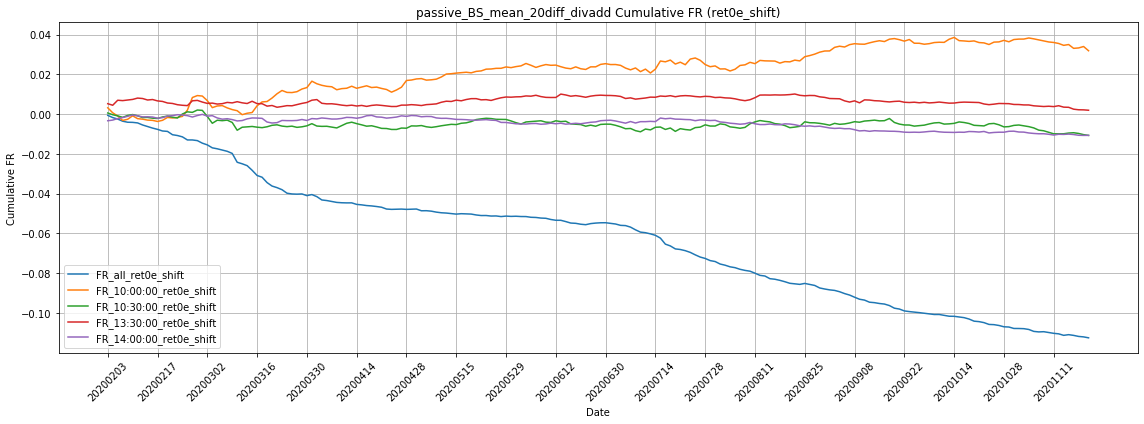

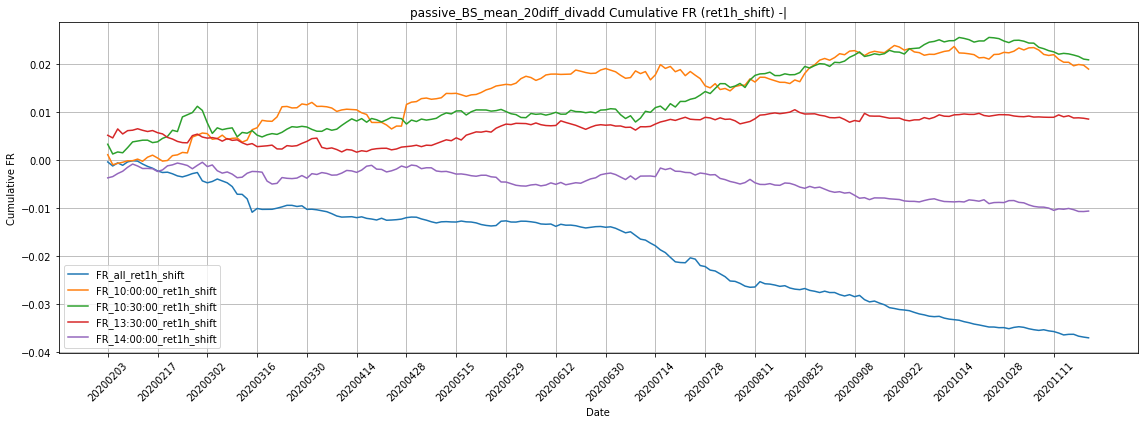

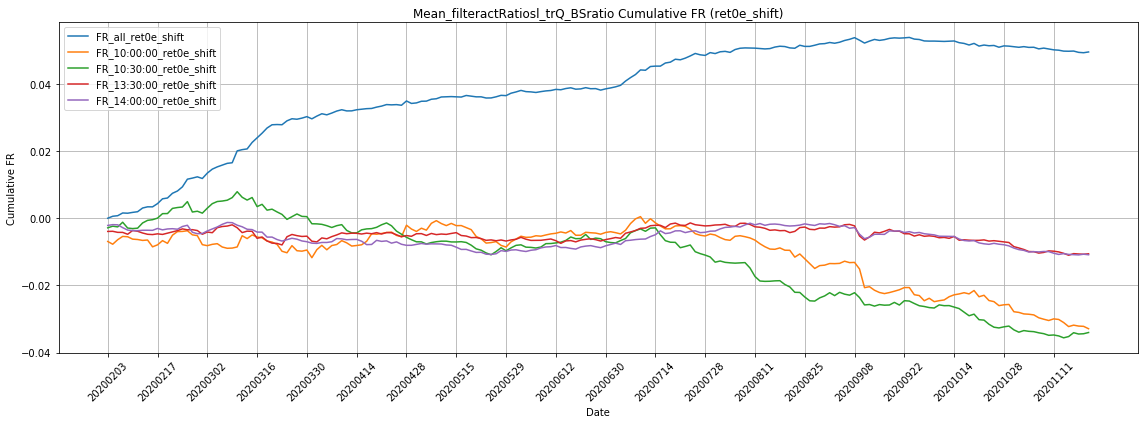

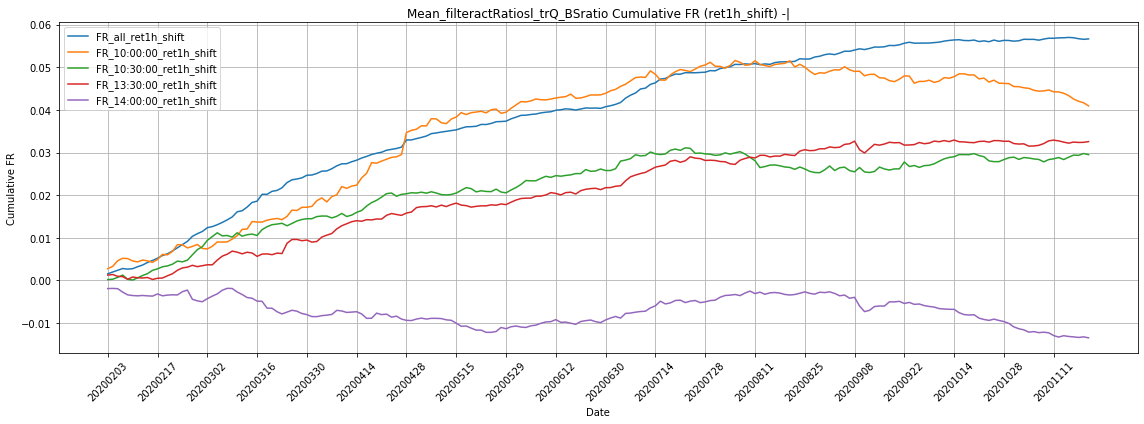

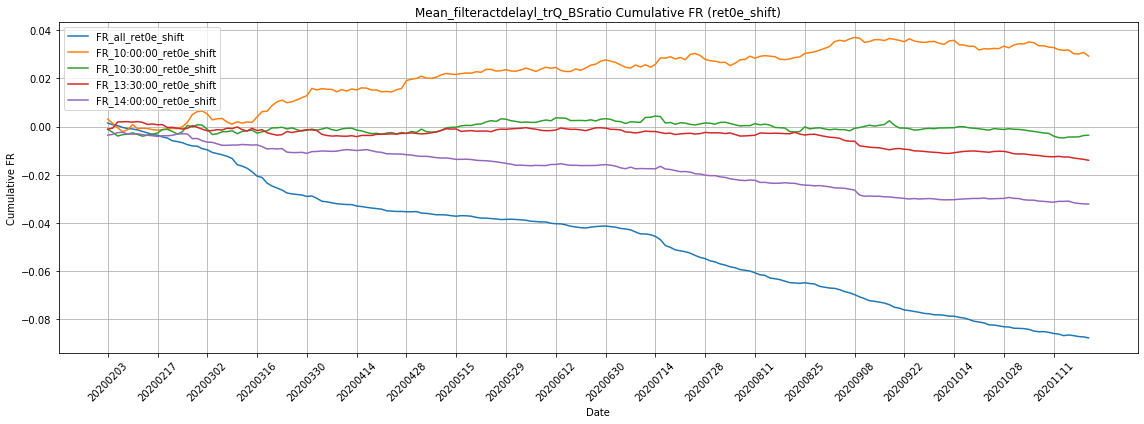

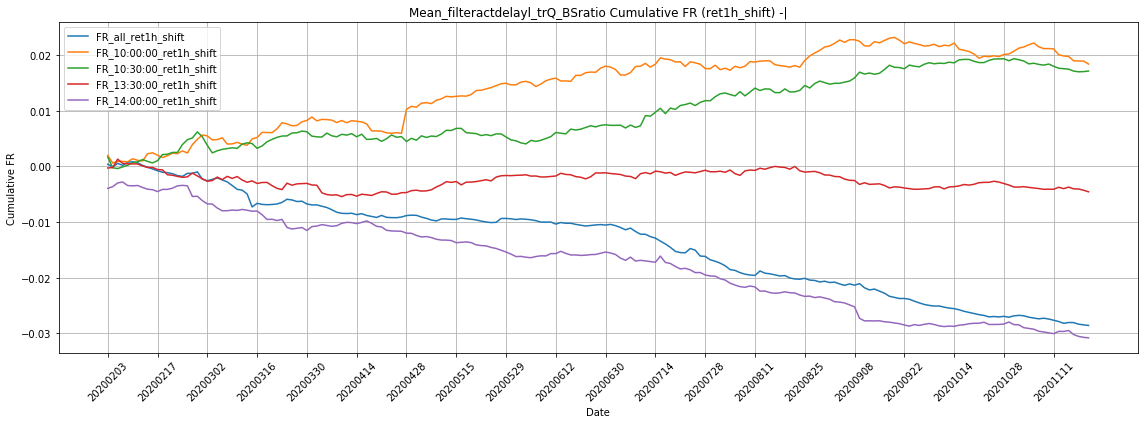

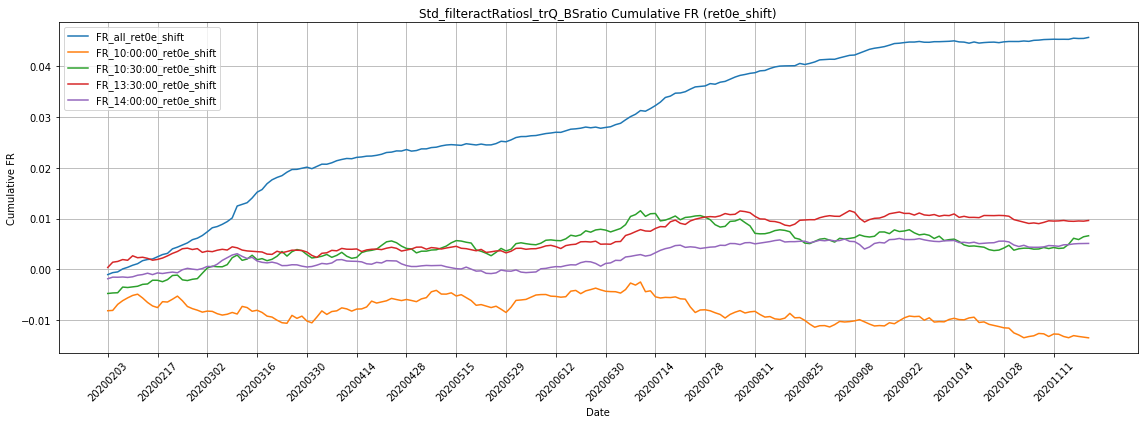

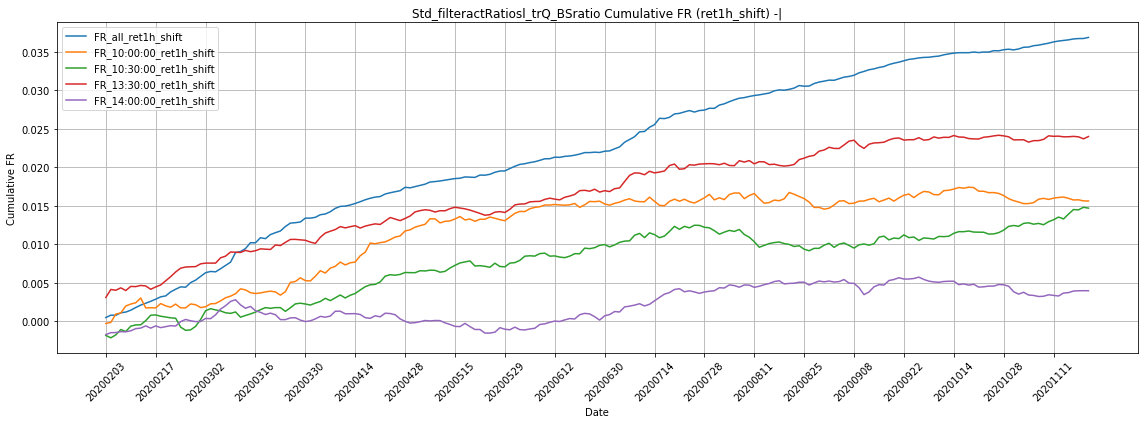

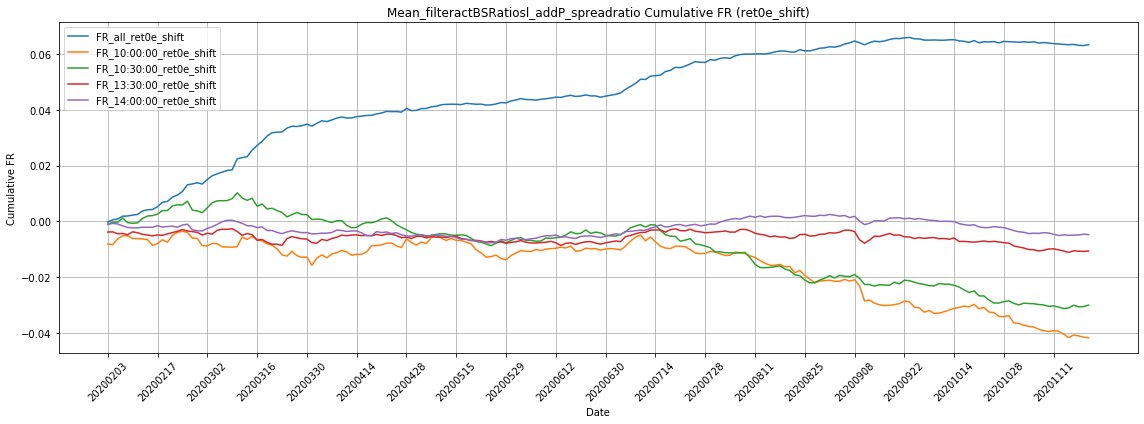

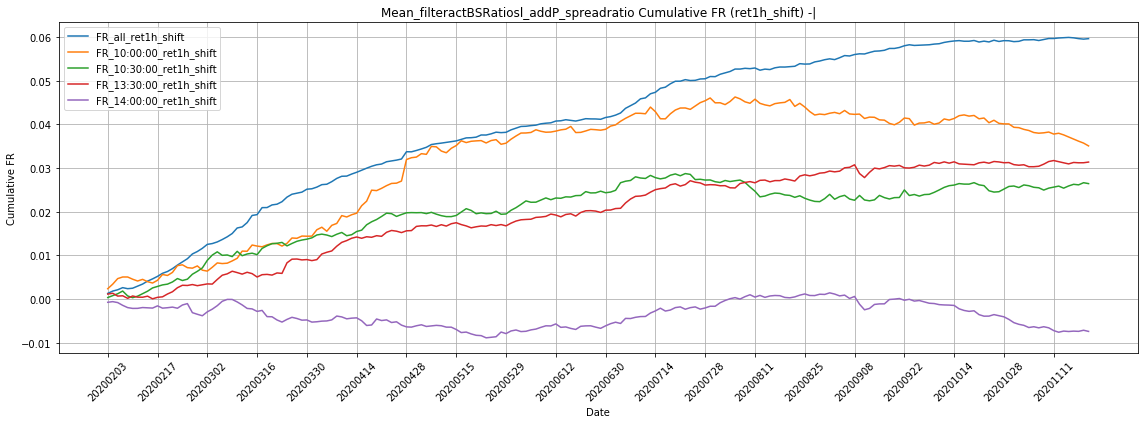

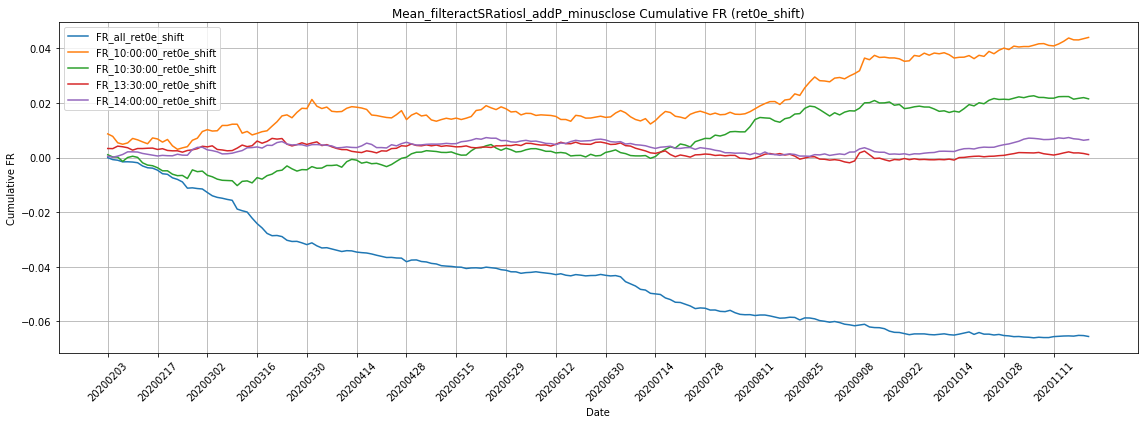

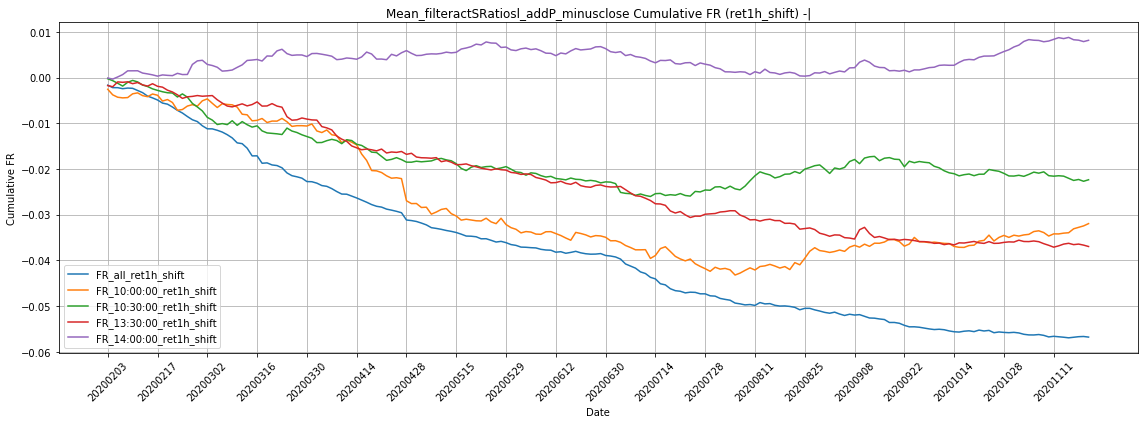

In [11]:
# raise Exception('pls')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def plot_cols(feat_col):
    # # 假设你已经有以下变量
    # feat_col = 'Around3s_AvgPrc_minusclose'
    ret_cols = ['ret0e_shift', 'ret1h_shift']
    time_points = ['10:00:00', '10:30:00', '13:30:00', '14:00:00']

    df = feature_all_df.reset_index()

    # ---------- 全部时间点 (FR_all_*) ----------
    fr_all_results = {}
    for ret_col in ret_cols:
        sub_df = df[[feat_col, ret_col, 'date']].dropna()

        # 按date groupby，计算 FR = cov(x, y) / std(x)
        grouped = sub_df.groupby('date')
        mean_x = grouped[feat_col].transform('mean')
        mean_y = grouped[ret_col].transform('mean')
        std_x = grouped[feat_col].transform('std')

        cov_xy = ((sub_df[feat_col] - mean_x) * (sub_df[ret_col] - mean_y)).groupby(sub_df['date']).mean()
        std_x_daily = std_x.groupby(sub_df['date']).first()  # std(x)是一样的，随便取一个就行

        fr = cov_xy / std_x_daily.replace(0, np.nan)
        fr_all_results[f'FR_all_{ret_col}'] = fr

    # ---------- 特定时间点 (FR_{time}_{ret_col}) ----------
    fr_time_results = {}

    for tp in time_points:
        df_tp = df[df['time'] == tp].dropna(subset=[feat_col] + ret_cols)
        for ret_col in ret_cols:
            grouped = df_tp.groupby('date')
            x = df_tp[feat_col]
            y = df_tp[ret_col]
            mean_x = grouped[feat_col].transform('mean')
            mean_y = grouped[ret_col].transform('mean')
            std_x = grouped[feat_col].transform('std')

            cov_xy = ((x - mean_x) * (y - mean_y)).groupby(df_tp['date']).mean()
            std_x_daily = std_x.groupby(df_tp['date']).first()

            fr = cov_xy / std_x_daily.replace(0, np.nan)
            fr_time_results[f'FR_{tp}_{ret_col}'] = fr

    # 合并所有结果
    fr_all_df = pd.DataFrame(fr_all_results)
    fr_time_df = pd.DataFrame(fr_time_results)
    fr_df = pd.concat([fr_all_df, fr_time_df], axis=1)

    # 计算 cumulative FR
    cumulative_fr_df = fr_df.cumsum()


    # 分别提取 ret0e 和 ret1h 的 FR 列
    fr_0e_cols = [col for col in cumulative_fr_df.columns if 'ret0e_shift' in col]
    fr_1h_cols = [col for col in cumulative_fr_df.columns if 'ret1h_shift' in col]

    # 画 ret0e_shift 的 Cumulative FR 图
    plt.figure(figsize=(16, 6))
    for col in fr_0e_cols:
        plt.plot(cumulative_fr_df.index, cumulative_fr_df[col], label=col)

    plt.title(f'{feat_col} Cumulative FR (ret0e_shift)')
    plt.xlabel('Date')
    plt.ylabel('Cumulative FR')
    plt.legend()
    plt.grid(True)
    plt.xticks(cumulative_fr_df.index[::10], rotation=45)
    plt.tight_layout()
    plt.show()

    # 画 ret1h_shift 的 Cumulative FR 图
    plt.figure(figsize=(16, 6))
    for col in fr_1h_cols:
        plt.plot(cumulative_fr_df.index, cumulative_fr_df[col], label=col)

    plt.title(f'{feat_col} Cumulative FR (ret1h_shift) -|')
    plt.xlabel('Date')
    plt.ylabel('Cumulative FR')
    plt.legend()
    plt.grid(True)
    plt.xticks(cumulative_fr_df.index[::10], rotation=45)
    plt.tight_layout()
    plt.show()
#     fr_df.to_parquet(f'/data/beef3/mike/pshared/GAlpha_custom_build/wensheng_jawN9J/fr_save/{feat_col}.parquet', engine="pyarrow", compression="snappy")
    
for feat_col in  ["passive_BS_mean_delay_divadd","passive_BS_std_delay_divadd", "passive_B_mean_ratio_divadd","passive_BS_mean_ratio_divadd","passive_BS_std_20diff_divadd",
    "passive_BS_mean_20diff_divadd",
    "Mean_filteractRatiosl_trQ_BSratio",
    "Mean_filteractdelayl_trQ_BSratio",
    "Std_filteractRatiosl_trQ_BSratio",
    "Mean_filteractBSRatiosl_addP_spreadratio",
    "Mean_filteractSRatiosl_addP_minusclose" ]:
    plot_cols(feat_col)